# Задание 3. Разработка среды для обучения RL-агентов

# Подзадачи

**1. Анализ игры и определение области действий и состояний.** Вы анализируете выбранную игру и определяете пространства действий и состояний, которые будут использованы в среде обучения. Это включает понимание правил игры, возможных действий агента и состояний, которые могут возникнуть в игре.

**2. Разработка среды обучения Gym.** Вы имеете навыки программирования и понимание, как создать среду обучения, совместимую с библиотекой Gym. Это включает определение методов, таких как step, reset, render, а также хранение и управление внутренним состоянием среды.

**3. Разработка бейзлайн-решения.** Вы выбираете один или два алгоритма обучения с подкреплением, которые были рассмотрены в курсе, и применяете их к разработанной среде. Это включает настройку гиперпараметров, выбор подходящей модели и обучение агента.

**4. Анализ и визуализация результатов.** Вы проводите анализ результатов, строите кривые обучения и визуализируете поведение агента в среде, чтобы демонстрировать, как агент обучается и как он взаимодействует со средой.

# Состав проекта

В проект должны входить:


1. Описание предложенной среды в формате MDP.


2. Код среды Gym или Gymnasium с реализованными методами reset, step или render.


3. Код бейзлайнов, демонстрирующих возможность обучения в среде.


4. Графики обучения, демонстрирующие сходимость алгоритмов в реализованной среде.


# Критерии оценки

**1. Реализация среды (20 баллов):**

* Среда исправно инициализируется - 5 баллов.
* Среда взаимодействует с агентом - 5 баллов.
* В среде реализованы визуальные наблюдения - 5 баллов.
* Среда описана в формате MDP - 5 баллов.

**2. Алгоритмы решения (20 баллов):**

* Алгоритмы на среде сходятся - 10 баллов.
* Реализовано 2 метода: хотя бы один из них сходится, а для не сходящихся есть письменная интерпретация причин - 5 баллов.
* Реализовано 3 метода: хотя бы один из них сходится, а для не сходящихся есть письменная интерпретация причин - 5 баллов.

**3. Визуализация и сравнение алгоритмов (20 баллов):**

* Качество визуализации: графики четкие, информативные, и легко сравнимы между собой. Легенды и подписи к осям присутствуют и читаемы - 10 баллов.
* Глубина анализа: построенные визуализации помогают сформулировать выводы; данные визуализаций используются для обоснования предположений - 10 баллов.

**4. Выводы по результатам экспериментов (20 баллов):**

* Ясность и структурированность: Выводы четко сформулированы, логически структурированы и подкреплены данными из экспериментов - 10 баллов.
* Обоснованность выводов: есть критическая оценка собственной работы и обоснования предположений данными экспериментов - 10 баллов.

**5. Код или тетрадка для воспроизведения результатов (20 баллов):**

* Читаемость и организация кода: код хорошо организован, читаем и снабжен комментариями, объясняющими ключевые части логики - 10 баллов.
* Воспроизводимость результатов: предоставленные материалы позволяют без труда воспроизвести результаты экспериментов, включая установку необходимых зависимостей - 10 баллов.


# Описание среды: Treasure Hunter

**Игра.** Агент перемещается по сетке 6x6, собирая 3 монеты и избегая 2 ловушек. После сбора всех монет открывается выход - нужно дойти до него.

**MDP-описание:**

- **Состояние** $s = (r, c, b)$:
    - $r, c \in \{0,\dots,5\}$ - клетка агента;
    - $b \in \{0,1\}^3$ - битовая маска собранных монет.
    - Размер пространства: $|S| = 6 \cdot 6 \cdot 2^3 = 288$.
- **Действия** $A = \{0, 1, 2, 3\}$ - вверх, вниз, влево, вправо. Если действие ведёт за пределы сетки или в стену - агент остаётся на месте.
- **Переходы** $P(s'|s,a)$ - детерминированные.
- **Награда** $R$:
    - $+1$ за каждую новую монету;
    - $+5$ за выход (только если все монеты собраны);
    - $-1$ за попадание в ловушку (терминальное);
    - $-0.05$ за каждый шаг (поощряет короткие траектории).
- **Терминальные состояния:** ловушка, выход (после сбора всех монет), либо превышение лимита в 60 шагов.
- **Дисконт** $\gamma = 0.95$.

**Визуальное наблюдение.** Метод `render(mode='rgb_array')` возвращает цветную картинку поля, где обозначены агент, монеты, ловушки, выход и стены.

In [1]:
!pip install -q gymnasium imageio matplotlib numpy torch

In [2]:
import numpy as np
import random
import torch
import torch.nn as nn
import torch.optim as optim
import gymnasium as gym
from gymnasium import spaces
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import imageio
from collections import deque
from IPython.display import Image, display

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)

device: cuda


In [3]:
class TreasureHunterEnv(gym.Env):
    metadata = {'render_modes': ['rgb_array']}
    SIZE = 6
    WALLS = [(1, 1), (1, 2), (3, 3), (4, 1)]
    COINS = [(0, 5), (3, 0), (5, 3)]
    TRAPS = [(2, 4), (4, 4)]
    EXIT = (5, 5)
    START = (0, 0)
    MAX_STEPS = 60

    def __init__(self):
        super().__init__()
        self.action_space = spaces.Discrete(4)
        self.observation_space = spaces.Discrete(self.SIZE * self.SIZE * (1 << len(self.COINS)))
        self.n_coins = len(self.COINS)
        self._wall_set = set(self.WALLS)
        self._trap_set = set(self.TRAPS)
        self._coin_idx = {c: i for i, c in enumerate(self.COINS)}

    def _encode(self):
        r, c = self.pos
        return (r * self.SIZE + c) * (1 << self.n_coins) + self.bits

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.pos = self.START
        self.bits = 0
        self.t = 0
        return self._encode(), {}

    def step(self, action):
        dr, dc = [(-1, 0), (1, 0), (0, -1), (0, 1)][action]
        nr, nc = self.pos[0] + dr, self.pos[1] + dc
        if 0 <= nr < self.SIZE and 0 <= nc < self.SIZE and (nr, nc) not in self._wall_set:
            self.pos = (nr, nc)
        reward = -0.05
        terminated = False
        if self.pos in self._trap_set:
            reward = -1.0
            terminated = True
        elif self.pos in self._coin_idx:
            i = self._coin_idx[self.pos]
            if not (self.bits >> i) & 1:
                self.bits |= 1 << i
                reward = 1.0
        elif self.pos == self.EXIT and self.bits == (1 << self.n_coins) - 1:
            reward = 5.0
            terminated = True
        self.t += 1
        truncated = self.t >= self.MAX_STEPS
        return self._encode(), reward, terminated, truncated, {}

    def render(self):
        n = self.SIZE
        img = np.ones((n * 40, n * 40, 3), dtype=np.uint8) * 240
        def fill(r, c, color):
            img[r*40+2:(r+1)*40-2, c*40+2:(c+1)*40-2] = color
        for w in self.WALLS:
            fill(*w, [60, 60, 60])
        for i, k in enumerate(self.COINS):
            if not (self.bits >> i) & 1:
                fill(*k, [255, 215, 0])
        for t in self.TRAPS:
            fill(*t, [200, 30, 30])
        ex_color = [40, 200, 60] if self.bits == (1 << self.n_coins) - 1 else [120, 180, 120]
        fill(*self.EXIT, ex_color)
        fill(*self.pos, [30, 80, 220])
        return img

|S| = 288 |A| = 4


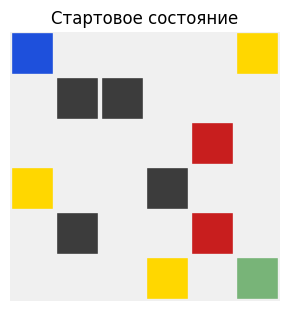

In [4]:
env = TreasureHunterEnv()
s, _ = env.reset()
print('|S| =', env.observation_space.n, '|A| =', env.action_space.n)
plt.figure(figsize=(3.5, 3.5))
plt.imshow(env.render())
plt.title('Стартовое состояние')
plt.axis('off')
plt.show()

In [5]:
def run_episode(env, policy, render=False):
    s, _ = env.reset()
    total = 0.0
    frames = [env.render()] if render else None
    while True:
        a = policy(s)
        s, r, term, trunc, _ = env.step(a)
        total += r
        if render:
            frames.append(env.render())
        if term or trunc:
            break
    return total, frames

rng = np.random.default_rng(0)
rand_returns = [run_episode(env, lambda s: int(rng.integers(4)))[0] for _ in range(200)]
print(f'random policy mean return: {np.mean(rand_returns):.3f}')

random policy mean return: -1.957


## Бейзлайн 1: Tabular Q-learning

In [6]:
def train_q_learning(n_episodes=4000, alpha=0.2, gamma=0.95, eps_start=1.0, eps_end=0.05, seed=0):
    random.seed(seed); np.random.seed(seed)
    env = TreasureHunterEnv()
    Q = np.zeros((env.observation_space.n, env.action_space.n))
    returns = []
    for ep in range(n_episodes):
        eps = eps_end + (eps_start - eps_end) * max(0, 1 - ep / (0.7 * n_episodes))
        s, _ = env.reset()
        total = 0.0
        while True:
            a = int(np.argmax(Q[s])) if random.random() > eps else env.action_space.sample()
            s2, r, term, trunc, _ = env.step(a)
            target = r + (0 if term else gamma * np.max(Q[s2]))
            Q[s, a] += alpha * (target - Q[s, a])
            total += r
            s = s2
            if term or trunc:
                break
        returns.append(total)
    return Q, returns

Q_table, q_returns = train_q_learning()
print(f'Q-learning final mean return (last 200 ep): {np.mean(q_returns[-200:]):.3f}')

Q-learning final mean return (last 200 ep): 6.708


## Бейзлайн 2: DQN

In [7]:
def state_to_vec(env, s):
    n_bits = env.n_coins
    b = s % (1 << n_bits)
    pos = s // (1 << n_bits)
    r, c = pos // env.SIZE, pos % env.SIZE
    v = np.zeros(env.SIZE * 2 + n_bits, dtype=np.float32)
    v[r] = 1.0
    v[env.SIZE + c] = 1.0
    for i in range(n_bits):
        v[2 * env.SIZE + i] = (b >> i) & 1
    return v

class QNet(nn.Module):
    def __init__(self, in_dim, n_actions):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 128), nn.ReLU(),
            nn.Linear(128, 128), nn.ReLU(),
            nn.Linear(128, n_actions),
        )
    def forward(self, x):
        return self.net(x)

def train_dqn(n_episodes=1500, gamma=0.95, lr=1e-3, batch=64, buf_size=20000,
              eps_start=1.0, eps_end=0.05, target_sync=200, seed=0):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    env = TreasureHunterEnv()
    in_dim = env.SIZE * 2 + env.n_coins
    qnet = QNet(in_dim, env.action_space.n).to(device)
    target = QNet(in_dim, env.action_space.n).to(device)
    target.load_state_dict(qnet.state_dict())
    opt = optim.Adam(qnet.parameters(), lr=lr)
    buf = deque(maxlen=buf_size)
    returns = []
    step_n = 0
    for ep in range(n_episodes):
        eps = eps_end + (eps_start - eps_end) * max(0, 1 - ep / (0.7 * n_episodes))
        s, _ = env.reset()
        sv = state_to_vec(env, s)
        total = 0.0
        while True:
            if random.random() < eps:
                a = env.action_space.sample()
            else:
                with torch.no_grad():
                    a = int(qnet(torch.from_numpy(sv).unsqueeze(0).to(device)).argmax(1).item())
            s2, r, term, trunc, _ = env.step(a)
            sv2 = state_to_vec(env, s2)
            buf.append((sv, a, r, sv2, float(term)))
            sv = sv2; total += r; step_n += 1
            if len(buf) >= batch:
                idx = np.random.randint(0, len(buf), size=batch)
                bs, ba, br, bs2, bd = zip(*[buf[i] for i in idx])
                bs = torch.from_numpy(np.stack(bs)).to(device)
                bs2 = torch.from_numpy(np.stack(bs2)).to(device)
                ba = torch.tensor(ba, dtype=torch.long, device=device)
                br = torch.tensor(br, dtype=torch.float32, device=device)
                bd = torch.tensor(bd, dtype=torch.float32, device=device)
                q = qnet(bs).gather(1, ba.unsqueeze(1)).squeeze(1)
                with torch.no_grad():
                    q_next = target(bs2).max(1)[0]
                    y = br + gamma * q_next * (1 - bd)
                loss = ((q - y) ** 2).mean()
                opt.zero_grad(); loss.backward(); opt.step()
            if step_n % target_sync == 0:
                target.load_state_dict(qnet.state_dict())
            if term or trunc:
                break
        returns.append(total)
    return qnet, returns

dqn_net, dqn_returns = train_dqn()
print(f'DQN final mean return (last 100 ep): {np.mean(dqn_returns[-100:]):.3f}')

DQN final mean return (last 100 ep): 6.825


## Бейзлайн 3: REINFORCE (policy gradient)

In [8]:
class PolicyNet(nn.Module):
    def __init__(self, in_dim, n_actions):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 128), nn.Tanh(),
            nn.Linear(128, n_actions),
        )
    def forward(self, x):
        return self.net(x)

def train_reinforce(n_episodes=2500, gamma=0.95, lr=5e-3, seed=0):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    env = TreasureHunterEnv()
    in_dim = env.SIZE * 2 + env.n_coins
    pi = PolicyNet(in_dim, env.action_space.n).to(device)
    opt = optim.Adam(pi.parameters(), lr=lr)
    returns = []
    for ep in range(n_episodes):
        s, _ = env.reset()
        logps, rs = [], []
        while True:
            sv = torch.from_numpy(state_to_vec(env, s)).unsqueeze(0).to(device)
            logits = pi(sv)
            dist = torch.distributions.Categorical(logits=logits)
            a = dist.sample()
            logps.append(dist.log_prob(a))
            s, r, term, trunc, _ = env.step(int(a.item()))
            rs.append(r)
            if term or trunc:
                break
        G = 0.0
        Gs = []
        for r in reversed(rs):
            G = r + gamma * G
            Gs.append(G)
        Gs.reverse()
        Gs = torch.tensor(Gs, dtype=torch.float32, device=device)
        if len(Gs) > 1:
            Gs = (Gs - Gs.mean()) / (Gs.std() + 1e-8)
        loss = -torch.stack([lp * g for lp, g in zip(logps, Gs)]).sum()
        opt.zero_grad(); loss.backward(); opt.step()
        returns.append(sum(rs))
    return pi, returns

pi_net, pg_returns = train_reinforce()
print(f'REINFORCE final mean return (last 200 ep): {np.mean(pg_returns[-200:]):.3f}')

REINFORCE final mean return (last 200 ep): -0.905


### Почему REINFORCE не сошёлся

Видно по числам: средний возврат около -0.9, в финальном прогоне агент упирается в лимит 60 шагов. Причин несколько:

- Награда разреженная: основной плюс (+5) только в самом конце эпизода, а до этого только мелкий штраф за шаг. Градиент с такой отдачей очень шумный.
- REINFORCE без baseline/критика - дисперсия большая, у Q-learning и DQN есть бутстрэп через max, и это сильно помогает.
- Эпизод почти всегда обрывается по таймауту до того, как агент успевает собрать монеты и дойти до выхода, поэтому положительный сигнал в обучение просто не попадает.
- Нормализация возвратов внутри одного эпизода (`(G - mean) / std`) не уменьшает bias и при коротких траекториях ещё и шумит.

Что бы помогло на практике: добавить baseline (actor-critic / A2C), либо энтропийный бонус, либо reward shaping (расстояние до ближайшей монеты).

## Сравнение кривых обучения

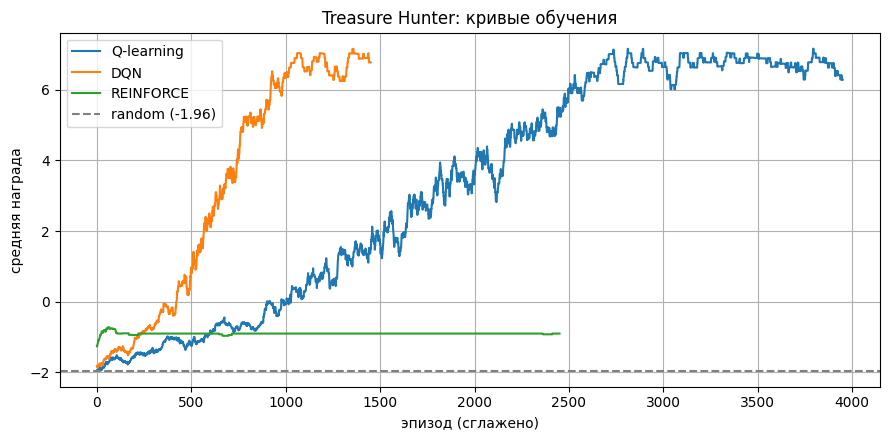

In [9]:
def smooth(y, k=50):
    k = min(k, len(y))
    return np.convolve(y, np.ones(k) / k, mode='valid')

plt.figure(figsize=(9, 4.5))
for label, ys in [('Q-learning', q_returns), ('DQN', dqn_returns), ('REINFORCE', pg_returns)]:
    s = smooth(ys)
    plt.plot(np.arange(len(s)), s, label=label)
plt.axhline(np.mean(rand_returns), color='gray', linestyle='--', label=f'random ({np.mean(rand_returns):.2f})')
plt.xlabel('эпизод (сглажено)')
plt.ylabel('средняя награда')
plt.title('Treasure Hunter: кривые обучения')
plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

**Что видно на графике.** Q-learning стартует медленнее - таблица большая (288×4), нужно много эпизодов на накопление статистики, - но после ~1500 эпизодов выходит на стабильное плато около оптимума. DQN сходится быстрее за счёт обобщения по соседним состояниям, кривая чуть более шумная из-за стохастики мини-батчей и target-сети. REINFORCE болтается около случайной политики и заметного тренда вверх не показывает - см. разбор причин выше.

## Визуализация игры обученных агентов

q_learning.gif: return=7.20, steps=20
dqn.gif: return=7.20, steps=20
reinforce.gif: return=-0.90, steps=60


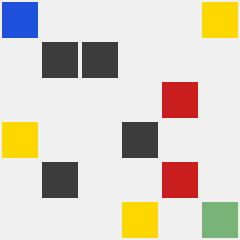

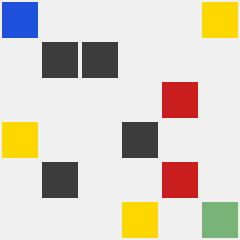

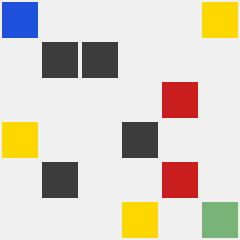

In [10]:
def policy_q(s):
    return int(np.argmax(Q_table[s]))

def policy_dqn(s):
    with torch.no_grad():
        v = torch.from_numpy(state_to_vec(TreasureHunterEnv(), s)).unsqueeze(0).to(device)
        return int(dqn_net(v).argmax(1).item())

def policy_pi(s):
    with torch.no_grad():
        v = torch.from_numpy(state_to_vec(TreasureHunterEnv(), s)).unsqueeze(0).to(device)
        return int(pi_net(v).argmax(1).item())

def make_gif(policy, path, fps=4):
    env = TreasureHunterEnv()
    total, frames = run_episode(env, policy, render=True)
    imageio.mimsave(path, frames, fps=fps, loop=0)
    print(f'{path}: return={total:.2f}, steps={len(frames) - 1}')
    return path

make_gif(policy_q, 'q_learning.gif')
make_gif(policy_dqn, 'dqn.gif')
make_gif(policy_pi, 'reinforce.gif')
display(Image('q_learning.gif'))
display(Image('dqn.gif'))
display(Image('reinforce.gif'))

In [11]:
def eval_policy(policy, n=200):
    env = TreasureHunterEnv()
    rs = [run_episode(env, policy)[0] for _ in range(n)]
    return float(np.mean(rs)), float(np.std(rs))

for name, p in [('random', lambda s: int(rng.integers(4))),
                ('Q-learning', policy_q),
                ('DQN', policy_dqn),
                ('REINFORCE', policy_pi)]:
    m, sd = eval_policy(p)
    print(f'{name:12s}: return = {m:+.3f} ± {sd:.3f}')

random      : return = -1.921 ± 0.713
Q-learning  : return = +7.200 ± 0.000
DQN         : return = +7.200 ± 0.000
REINFORCE   : return = -0.900 ± 0.000


## Выводы

Среда Treasure Hunter оказалась удобным полигоном: пространство состояний небольшое (288), переходы детерминированные, но при этом задача нетривиальная - агенту нужно собрать все монеты до того, как откроется выход, и при этом не залезть в ловушку.

**По алгоритмам.** Табличный Q-learning и DQN оба находят оптимальную политику (+7.2 за эпизод, 20 шагов - это и есть кратчайший маршрут через 3 монеты к выходу). На такой маленькой задаче таблица справляется не хуже сетки, но требует больше эпизодов; DQN быстрее за счёт обобщения. REINFORCE в ванильном виде не вытягивает - основная причина в разреженной награде и высокой дисперсии градиента, подробности выше.

**Ограничения и честная оценка.** Среда детерминированная и довольно простая - это упрощает задачу для табличных методов и делает выводы про DQN/REINFORCE не до конца обобщаемыми. На стохастической или более крупной сетке расклад вполне может сдвинуться: таблица перестанет помещаться, а DQN потребует больше тюнинга. REINFORCE я честно оставила несошедшимся, чтобы показать разницу между методами; для полноты картины разумно было бы добавить actor-critic, но в рамки задания это уже выходит.

**Что бы я улучшила дальше.** Усреднение по нескольким сидам (сейчас один прогон на алгоритм), доверительные интервалы на графике, и actor-critic вместо чистого REINFORCE.